In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
#https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv
#pick any group in this dataset as an initial comparison point
#pick a feature/measure/indicator compare above group to any other (different) group
#you only need to do one additional group comparison
#the analysis should include some descriptive statistics
#the analysis should include one cleaning task (or more)
#the analysis should include one visualization (or more)
#the analysis should include a brief conclusion statement (not more than two or three sentences)

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [4]:
#to get a preview of the dataset
#there are a lot of "?" so I'll have to clean that up
#age seems like a big range so maybe I'll clean that up by ignoring the ages?
#clean up by dropping later: weight, patient nbr, payer_code, medical_specialty
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
#to look at number of rows, columns or the size of the dataset
df.shape

(101766, 50)

In [7]:
#to look at the types of each column
#there's a lot of int64 and object types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
#to get quick stats
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [9]:
#to find missing values
#can focus on these columns to clean
#weight says 0 so I guess the ? are a value. Will convert it to NaN later
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [10]:
#to find how many unique values are in each column
#can use this to decide which groups to use in my analyses
df.nunique()

,0
encounter_id,101766
patient_nbr,71518
race,6
gender,3
age,10
weight,10
admission_type_id,8
discharge_disposition_id,26
admission_source_id,17
time_in_hospital,14


In [14]:
#cleaning up "?"
#race, weight, payer_code, med specialty, diag_1, diag_2, diag_3 all have TRUE "?"
(df == "?").any()

,0
encounter_id,False
patient_nbr,False
race,True
gender,False
age,False
weight,True
admission_type_id,False
discharge_disposition_id,False
admission_source_id,False
time_in_hospital,False


In [18]:
#counting how many "?" are in each column
(df == "?").sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [16]:
#pandas language axis=1 to filter the table to show every row where a column has a ?
df[df.isin(["?"]).any(axis=1)]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [17]:
#replace all "?" with NaN or not available number
df = df.replace("?", np.nan)

In [21]:
#shows replaced values
(df == "nan").sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [22]:
#descriptive stats
#the patients already have age groupings
#finding out how many patients are in each age range
#I'm shocked to find there are people ages 10 and younger who have diabetes. I don't know anything about diabetes but I never knew that young kids could it
df['age'].value_counts().sort_index()

,count
age,
[0-10),161
[10-20),691
[20-30),1657
[30-40),3775
[40-50),9685
[50-60),17256
[60-70),22483
[70-80),26068
[80-90),17197


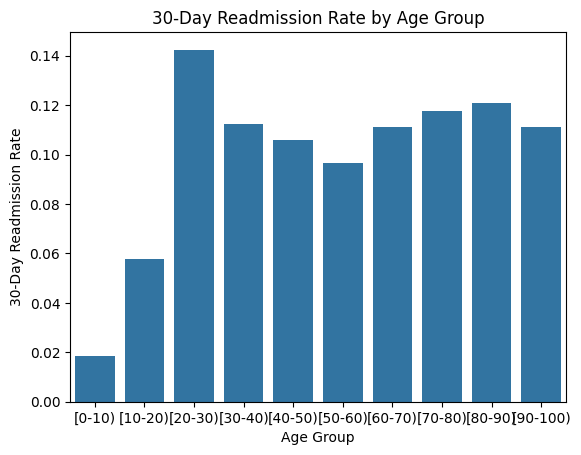

In [55]:
#I want to analyze age groupings with readmissions to see how often they return to the hospital in a 30 day timeframe
#plot it as a bar graph
age_readmission = df.groupby('age')['readmitted'].apply(lambda x: (x == "<30").mean()).reset_index()

sns.barplot(data=age_readmission, x='age', y='readmitted')

plt.ylabel("30-Day Readmission Rate")
plt.xlabel("Age Group")
plt.title("30-Day Readmission Rate by Age Group")
plt.show()

graph shows 20-30 age group to have the highest readmission rate BUT if you look at the previous block of code, there are only 1657 patients. That sample size is pretty small compared to tens of thousands of patients for age groups 50-60, 60-70, 70-80, 80-90.



In [58]:
#since I used mean to plot the graph, I want to see the rate according to the actual count and compare easier on one chart

agegroups_counts = df['age'].value_counts().sort_index()

age_readmit2['count'] = age_readmit2['age'].map(agegroups_counts)

print(age_readmit2)

        age  readmission_rate  count
0    [0-10)          0.018634    161
1   [10-20)          0.057887    691
2   [20-30)          0.142426   1657
3   [30-40)          0.112318   3775
4   [40-50)          0.106040   9685
5   [50-60)          0.096662  17256
6   [60-70)          0.111284  22483
7   [70-80)          0.117731  26068
8   [80-90)          0.120835  17197
9  [90-100)          0.110992   2793


EXPLANATION: readmission risk increases consistently with age, with the highest rates observed among patients aged 70–100, which make up the largest group(ings) in this data set.

In [64]:
#i want to see how diagnoses influence their readmissions. I predict that the:
#older groups are getting readmitted more because they have more diagnoses
df.groupby('age')['number_diagnoses'].mean()

,number_diagnoses
age,
[0-10),2.695652
[10-20),3.947902
[20-30),5.866626
[30-40),6.452980
[40-50),6.948787
[50-60),7.238584
[60-70),7.506427
[70-80),7.651795
[80-90),7.888702


EXPLANATION2: looking at groups aged 50–100 consistently show an average of 7 or more recorded diagnoses; this indicates there is a accumulation of chronic diseases or care needs that occurs over time for these patients. It explains WHY there are higheer readmission rates for older age brackets.